In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
thresh = 15

f = open('../Output/Determ/rand_cp_stb.pckl', 'rb')
connected_pairs_rand = pickle.load(f)
f.close()

f = open('../Output/Determ/rand_eff_stb.pckl', 'rb')
rand_eff = pickle.load(f)
f.close()

f = open('../Output/Determ/rand_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_rand = pickle.load(f)
f.close()

f = open('../Output/Determ/dist_cp_stb.pckl', 'rb')
connected_pairs_dist = pickle.load(f)
f.close()

f = open('../Output/Determ/dist_eff_stb.pckl', 'rb')
dist_eff = pickle.load(f)
f.close()

f = open('../Output/Determ/dist_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_dist = pickle.load(f)
f.close()

In [3]:
K = 10; p_in = 0.5
p_list = [0.2, 0.5, 0.7]
cp_prop_stat = {}; eff = {}; in_hubs = {}; out_hubs = {}

In [4]:
cp_prop_stat['rand'] = {}
eff['rand'] = {}
in_hubs['rand'] = {}
out_hubs['rand'] = {}
for p in p_list:
    cp_prop_stat['rand'][p] = np.zeros((2,31))
    eff['rand'][p] = np.zeros((2,31))
    in_hubs['rand'][p] = np.zeros((2,31))
    out_hubs['rand'][p] = np.zeros((2,31))
        
    cp_prop_temp = np.zeros((K,31))
    eff_temp = np.zeros((K,31))
    in_hubs_temp = np.zeros((K,31))
    out_hubs_temp = np.zeros((K,31))
        
    for k in range(K):
        for step_ind,step in enumerate(connected_pairs_rand[p_in][p][k].keys()):        
            cp_prop_temp[k,step_ind] = np.sum(connected_pairs_rand[p_in][p][k][step])/10000
            eff_temp[k,step_ind] = rand_eff[p_in][p][k][step]
            in_hubs_temp[k,step_ind] = Hubs_rand['in'][p_in][p][k][step]/100
            out_hubs_temp[k,step_ind] = Hubs_rand['out'][p_in][p][k][step]/100

        cp_prop_stat['rand'][p][0,:] = np.mean(cp_prop_temp,0)
        cp_prop_stat['rand'][p][1,:] = np.std(cp_prop_temp,0)    
        eff['rand'][p][0,:] = np.mean(eff_temp,0)
        eff['rand'][p][1,:] = np.std(eff_temp,0)
        in_hubs['rand'][p][0,:] = np.mean(in_hubs_temp,0)
        in_hubs['rand'][p][1,:] = np.std(in_hubs_temp,0)  
        out_hubs['rand'][p][0,:] = np.mean(out_hubs_temp,0)
        out_hubs['rand'][p][1,:] = np.std(out_hubs_temp,0)

In [5]:
cp_prop_stat['dist'] = {}
eff['dist'] = {}
in_hubs['dist'] = {}
out_hubs['dist'] = {}
for p in p_list:
    cp_prop_stat['dist'][p] = np.zeros((2,31))
    eff['dist'][p] = np.zeros((2,31))
    in_hubs['dist'][p] = np.zeros((2,31))
    out_hubs['dist'][p] = np.zeros((2,31))
        
    cp_prop_temp = np.zeros((K,31))
    eff_temp = np.zeros((K,31))
    in_hubs_temp = np.zeros((K,31))
    out_hubs_temp = np.zeros((K,31))
        
    for k in range(K):
        for step_ind,step in enumerate(connected_pairs_dist[p_in][p][k].keys()):        
            cp_prop_temp[k,step_ind] = np.sum(connected_pairs_dist[p_in][p][k][step])/10000
            eff_temp[k,step_ind] = dist_eff[p_in][p][k][step]
            in_hubs_temp[k,step_ind] = Hubs_dist['in'][p_in][p][k][step]/100
            out_hubs_temp[k,step_ind] = Hubs_dist['out'][p_in][p][k][step]/100

        cp_prop_stat['dist'][p][0,:] = np.mean(cp_prop_temp,0)
        cp_prop_stat['dist'][p][1,:] = np.std(cp_prop_temp,0)    
        eff['dist'][p][0,:] = np.mean(eff_temp,0)
        eff['dist'][p][1,:] = np.std(eff_temp,0)
        in_hubs['dist'][p][0,:] = np.mean(in_hubs_temp,0)
        in_hubs['dist'][p][1,:] = np.std(in_hubs_temp,0)  
        out_hubs['dist'][p][0,:] = np.mean(out_hubs_temp,0)
        out_hubs['dist'][p][1,:] = np.std(out_hubs_temp,0)

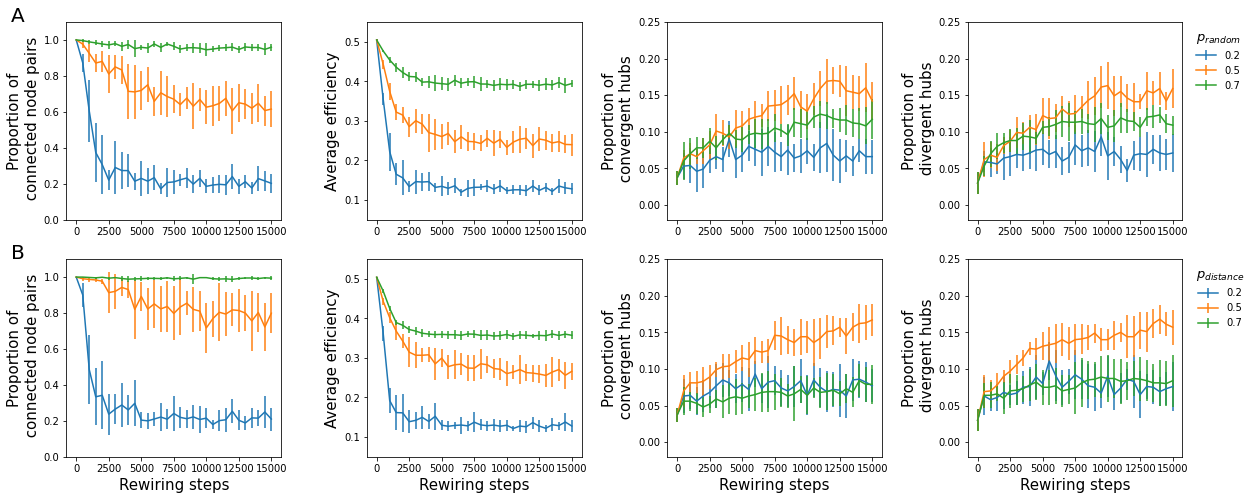

In [7]:
colorsPlot = [ 'orange', 'green','blue','red','cyan']
shapePoint = ['--s','-v','-o','-d','-h']
shapePointNoLine = ['s','v','o','d','h']
plt.rcParams['figure.figsize'] = [20, 8]
K = 10; step = 15000

plt.subplot(2,4,1)
for p in p_list:
    plt.errorbar(connected_pairs_rand[p_in][p][0].keys(),cp_prop_stat['rand'][p][0,:],cp_prop_stat['rand'][p][1,:],
                     label=str(p))
plt.ylim([0,1.1])
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.text(-5000,1.1,'A',fontsize=20)

plt.subplot(2,4,2)
for p in p_list:
    plt.errorbar(rand_eff[p_in][p][0].keys(),eff['rand'][p][0,:],eff['rand'][p][1,:],label=str(p))
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)

plt.subplot(2,4,3)
for p in p_list:
    plt.errorbar(Hubs_rand['in'][p_in][p][0].keys(),in_hubs['rand'][p][0,:],in_hubs['rand'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)

plt.subplot(2,4,4)
for p in p_list:
    plt.errorbar(Hubs_rand['out'][p_in][p][0].keys(),out_hubs['rand'][p][0,:],out_hubs['rand'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.legend(title='$p_{random}$',frameon=False,title_fontsize=13,loc='upper left',bbox_to_anchor=(1.02, 1))

plt.subplot(2,4,5)
for p in p_list:
    plt.errorbar(connected_pairs_dist[p_in][p][0].keys(),cp_prop_stat['dist'][p][0,:],cp_prop_stat['dist'][p][1,:],
                     label=str(p))
plt.ylim([0,1.1])
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.text(-5000,1.1,'B',fontsize=20)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,6)
for p in p_list:
    plt.errorbar(dist_eff[p_in][p][0].keys(),eff['dist'][p][0,:],eff['dist'][p][1,:],label=str(p))
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,7)
for p in p_list:
    plt.errorbar(Hubs_dist['in'][p_in][p][0].keys(),in_hubs['dist'][p][0,:],in_hubs['dist'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,8)
for p in p_list:
    plt.errorbar(Hubs_dist['out'][p_in][p][0].keys(),out_hubs['dist'][p][0,:],out_hubs['dist'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)
plt.legend(title='$p_{distance}$',frameon=False,title_fontsize=13,loc='upper left',bbox_to_anchor=(1.02, 1))

plt.subplots_adjust(wspace=0.4)